In [1]:
import pandas as pd
import numpy as np
# from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


# Explicación: Importante sobre la plantilla

Se tiene que tener en cuenta que este notebook no tiene ningún archivo asociado, ni se carga ningún DataFrame de prueba. Por lo tanto, es una plantilla que no debería ejecutarse como tal, es decir, de este apartado se debería poder identificar que código necesitan y usarlo en el notebook que entregarán en el parcial práctico.

Esta etapa del parcial es en la sala Waira. Deben utilizar los computadores de la sala y conectarse al usuario Examen. En los computadores está disponible Visual Studio Code con Python para editar y ejecutar los notebooks. 
Además, con el fin de que puedan resolver inquietudes de código, tendrán acceso a los siguientes sitios:

    https://scikit-learn.org/
    https://pandas.pydata.org/
    https://imbalanced-learn.org/stable/
    https://numpy.org/
    https://matplotlib.org/
    https://seaborn.pydata.org/
    https://pypi.org/

In [2]:
df = pd.read_csv('Dataset_preparacion_atletica.csv')

In [ ]:

# =========================================================
# Análisis exploratorio y calidad de datos
# =========================================================


In [3]:
data = df.copy()

## Paso 1: Dimensiones y estructura general
Lo primero siempre: ¿cuántas filas/columnas hay, qué tipo de dato tiene cada una, y cuántos valores no nulos trae? Esto te dice de entrada si algo no cuadra (ej. una columna numérica cargada como texto).

In [4]:
print(data.shape)
data.info()

(1000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Edad                                       994 non-null    float64
 1   Género                                     991 non-null    object 
 2   Tipo de deporte                            986 non-null    object 
 3   IMC                                        989 non-null    float64
 4   Horas de entrenamiento por semana          988 non-null    float64
 5   Frecuencia cardíaca en reposo              989 non-null    float64
 6   Ingesta de calorías                        988 non-null    float64
 7   Nivel de experiencia                       987 non-null    object 
 8   Frecuencia de competencia                  988 non-null    float64
 9   Indicador de establecimiento de objetivos  990 non-null    object 
 10  Puntuación de 

In [13]:
data.duplicated().sum()

4

In [18]:
data['log_id'].duplicated().sum()

5

In [28]:
# 1. Quedarte solo con las filas cuyo log_id se repite (keep=False marca TODAS las repetidas, no solo la 2da en adelante)
ids_repetidos = data[data['log_id'].duplicated(keep=False)]
ids_repetidos.sort_values('log_id')

,Edad,Género,Tipo de deporte,IMC,Horas de entrenamiento por semana,Frecuencia cardíaca en reposo,Ingesta de calorías,Nivel de experiencia,Frecuencia de competencia,Indicador de establecimiento de objetivos,Puntuación de preparación estratégica,Puntuación de rendimiento,log_id


In [19]:
data.isnull().sum()

Edad                                          6
Género                                        9
Tipo de deporte                              14
IMC                                          11
Horas de entrenamiento por semana            12
Frecuencia cardíaca en reposo                11
Ingesta de calorías                          12
Nivel de experiencia                         13
Frecuencia de competencia                    12
Indicador de establecimiento de objetivos    10
Puntuación de preparación estratégica         8
Puntuación de rendimiento                     0
log_id                                        0
dtype: int64

## Paso 2: Estadísticas descriptivas
`describe()` te da de un vistazo el rango (min/max), media y percentiles de las numéricas — aquí es donde detectas valores imposibles (ej. una edad de 492 años). Con `include='object'` haces lo mismo para las categóricas: cuántas categorías tiene cada una y cuál es la más frecuente.

In [21]:
print("Numericas")
display(data.describe())

print("Categoricas")
display(data.describe(include='object'))

print("Porcentaje de nulos")
(data.isnull().sum() / data.shape[0] * 100).sort_values(ascending=False)

Numericas


,Edad,IMC,Horas de entrenamiento por semana,Frecuencia cardíaca en reposo,Ingesta de calorías,Frecuencia de competencia,Puntuación de preparación estratégica,Puntuación de rendimiento,log_id
count,994.000000,989.000000,988.000000,989.000000,988.000000,988.000000,992.000000,1000.000000,1000.000000
mean,336.321932,23.003061,19.833527,67.700784,3171.146228,12.156196,65.071276,82.588758,127131.107000
std,89.011269,3.050985,9.098034,13.279323,832.866481,7.293387,14.847290,12.841929,71509.545941
min,20.000000,15.871890,4.381193,43.977092,1757.476349,-1.014180,19.059695,32.211629,86.000000
25%,252.000000,20.894943,12.241337,56.098947,2521.711594,5.958148,54.719473,73.737318,65272.500000
50%,348.000000,23.052422,19.388211,68.073445,3164.124280,12.178702,64.543453,83.704262,127463.500000
75%,408.000000,25.037110,27.502563,78.573412,3834.560158,18.840930,75.876574,92.918808,187957.500000
max,492.000000,34.981132,68.990598,114.023258,7225.519216,25.312736,100.758629,101.567375,249061.000000


Categoricas


,Género,Tipo de deporte,Nivel de experiencia,Indicador de establecimiento de objetivos
count,991,986,987,990
unique,4,6,4,2
top,Masculino,Ciclismo,Intermedio,Sí
freq,617,182,353,600


Porcentaje de nulos


Tipo de deporte                              1.4
Nivel de experiencia                         1.3
Horas de entrenamiento por semana            1.2
Ingesta de calorías                          1.2
Frecuencia de competencia                    1.2
IMC                                          1.1
Frecuencia cardíaca en reposo                1.1
Indicador de establecimiento de objetivos    1.0
Género                                       0.9
Puntuación de preparación estratégica        0.8
Edad                                         0.6
Puntuación de rendimiento                    0.0
log_id                                       0.0
dtype: float64

In [20]:
(data['Frecuencia de competencia'] < 0).sum()

28

## Paso 3: Valores únicos de las variables categóricas
Muy importante para calidad de datos: revisa si una misma categoría está escrita de formas distintas (ej. "Masculino" y "M" siendo lo mismo). `describe()` no te lo muestra, `value_counts()` sí.

In [ ]:
cat_cols = ['Género', 'Tipo de deporte', 'Nivel de experiencia', 'Indicador de establecimiento de objetivos']

for col in cat_cols:
    print(f'--- {col} ---')
    print(data[col].value_counts(dropna=False))
    print()

print("Porcentaje de nulos")


--- Género ---
Género
Masculino    617
Femenino     315
M             33
F             26
NaN            9
Name: count, dtype: int64

--- Tipo de deporte ---
Tipo de deporte
Ciclismo            182
Atletismo           166
Tenis               165
Fútbol americano    165
Baloncesto          155
Natación            153
NaN                  14
Name: count, dtype: int64

--- Nivel de experiencia ---
Nivel de experiencia
Intermedio      353
Avanzado        293
Principiante    219
Profesional     122
NaN              13
Name: count, dtype: int64

--- Indicador de establecimiento de objetivos ---
Indicador de establecimiento de objetivos
Sí     600
No     390
NaN     10
Name: count, dtype: int64



## Paso 4: Distribución de las variables numéricas
Los histogramas te muestran forma (¿simétrica, sesgada?), y si hay valores raros aislados en los extremos (una barra solitaria muy lejos del resto = candidato a error, como la Edad de ~490).

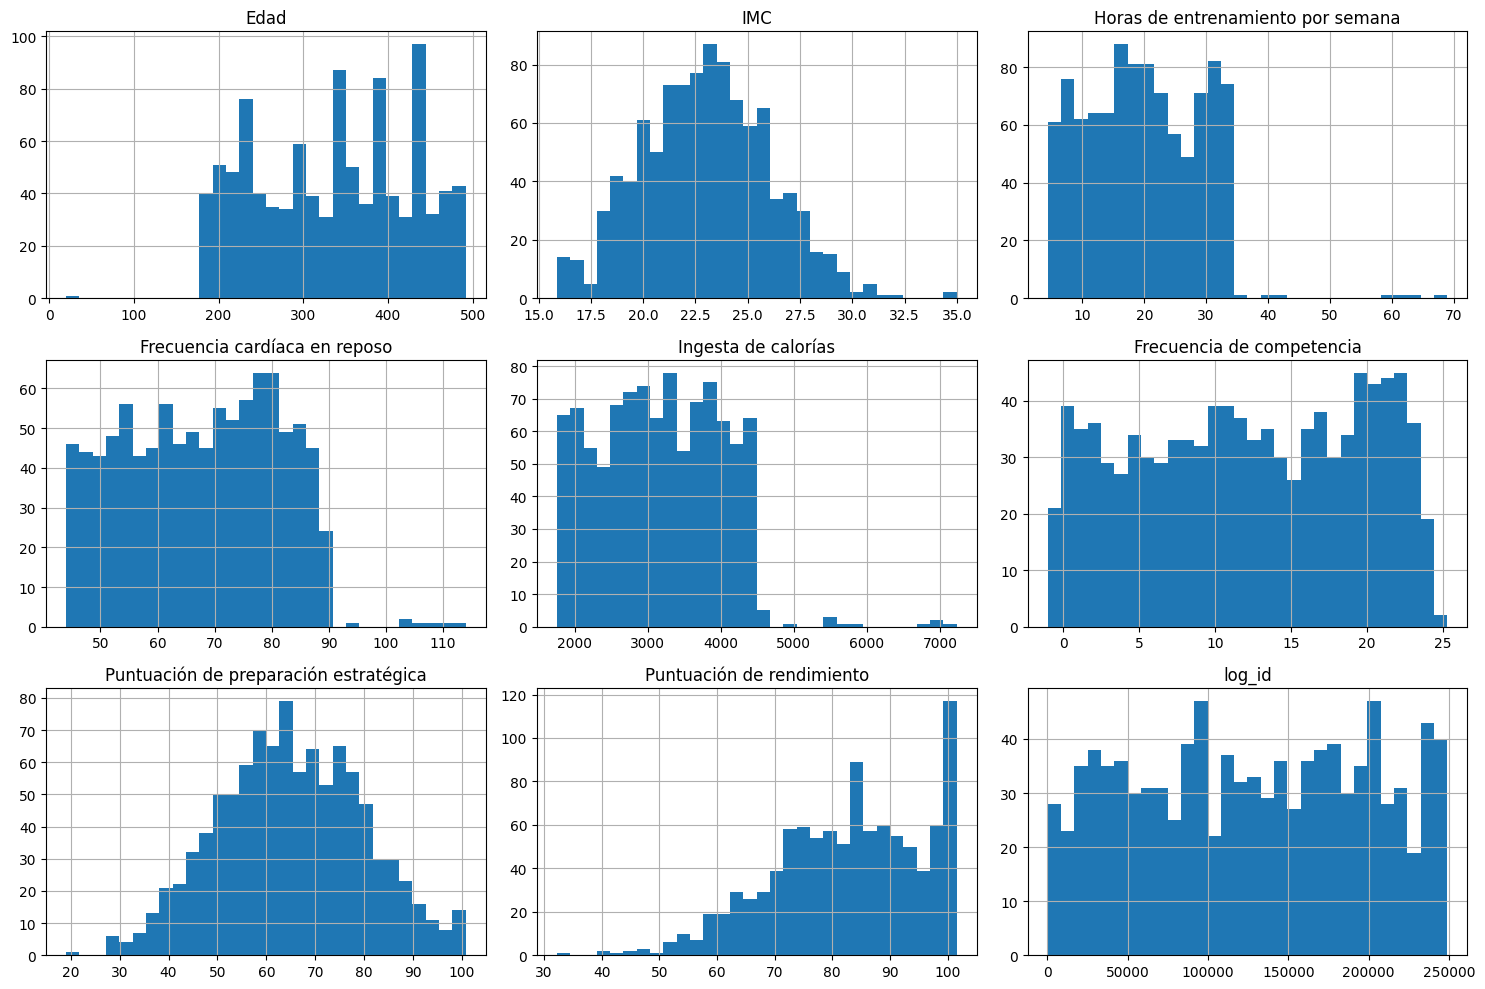

In [8]:
data.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

## Paso 5: Distribución de las variables categóricas
`countplot` para ver si hay categorías con muy pocos registros (podría afectar el modelo) y confirmar visualmente lo que viste en `value_counts()`.

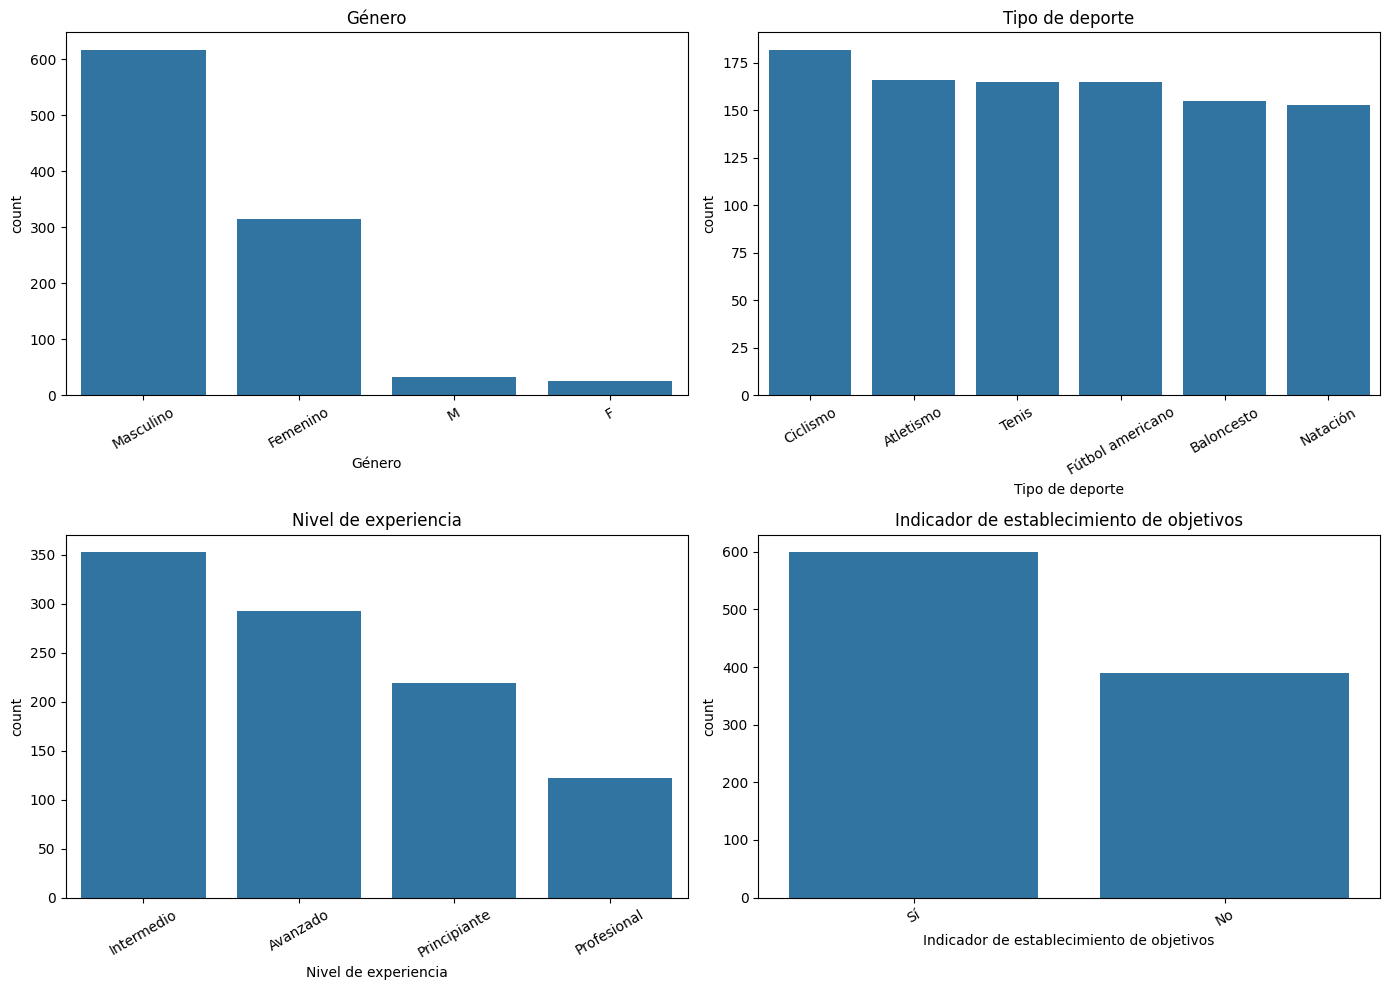

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=data, x=col, order=data[col].value_counts().index, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Paso 6: Relación de cada variable con el target
Como el objetivo es predecir `Puntuación de rendimiento`, aquí es donde empiezas a ver qué variables parecen tener relación con el target — esto alimenta directamente la justificación de tu enfoque analítico (punto 1b) y de las transformaciones (punto 3).

- Numéricas vs target → scatterplot (relación lineal o no).
- Categóricas vs target → boxplot (¿cambia la mediana del target entre categorías?).

In [23]:
data["Puntuación de rendimiento"].isnull().sum()

0

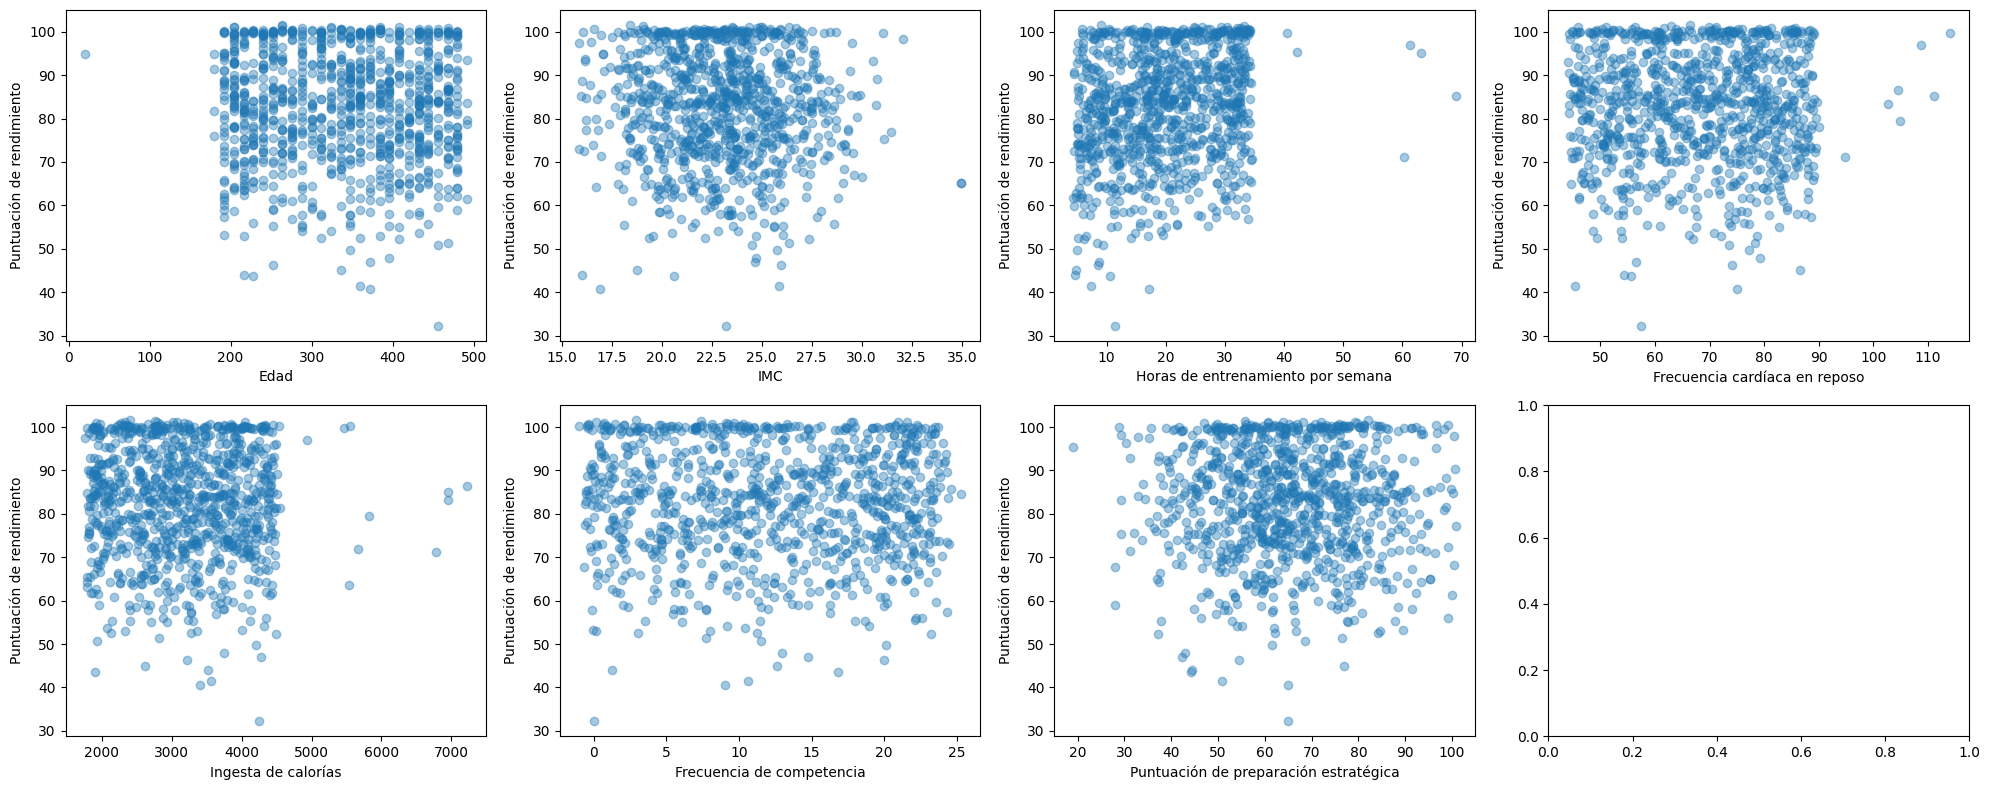

In [10]:
target = 'Puntuación de rendimiento'
num_cols = ['Edad', 'IMC', 'Horas de entrenamiento por semana', 'Frecuencia cardíaca en reposo',
            'Ingesta de calorías', 'Frecuencia de competencia', 'Puntuación de preparación estratégica']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.scatter(data[col], data[target], alpha=0.4)
    ax.set_xlabel(col)
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()

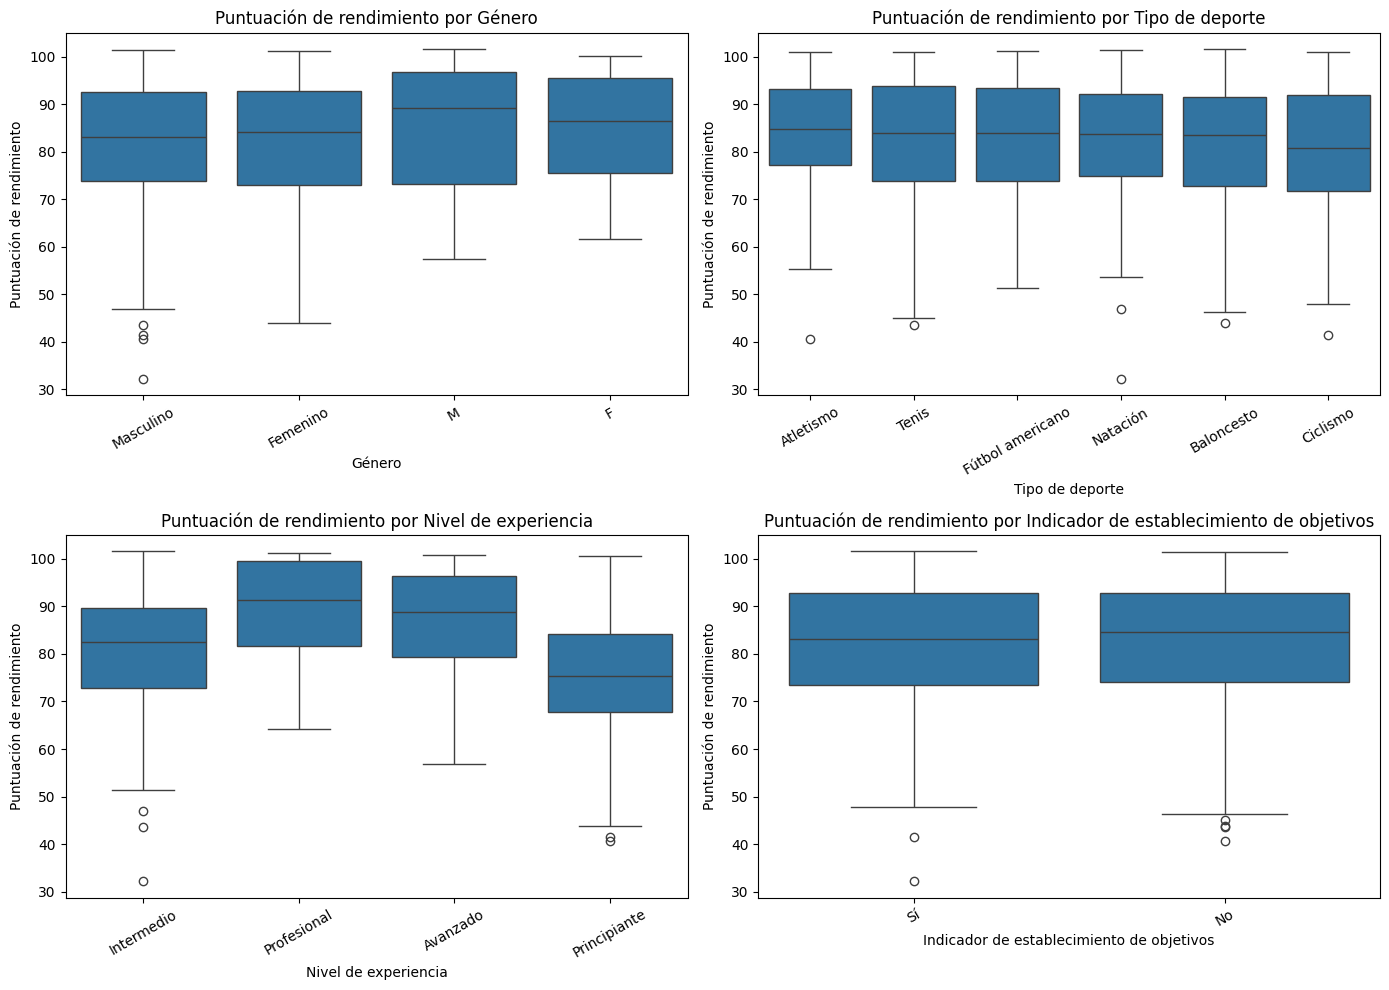

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=data, x=col, y=target, ax=ax)
    ax.set_title(f'{target} por {col}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Paso 7: Correlación entre variables numéricas
El heatmap resume en un solo vistazo qué tan relacionadas están las numéricas entre sí (útil para justificar Ridge/Lasso si hay multicolinealidad) y con el target.

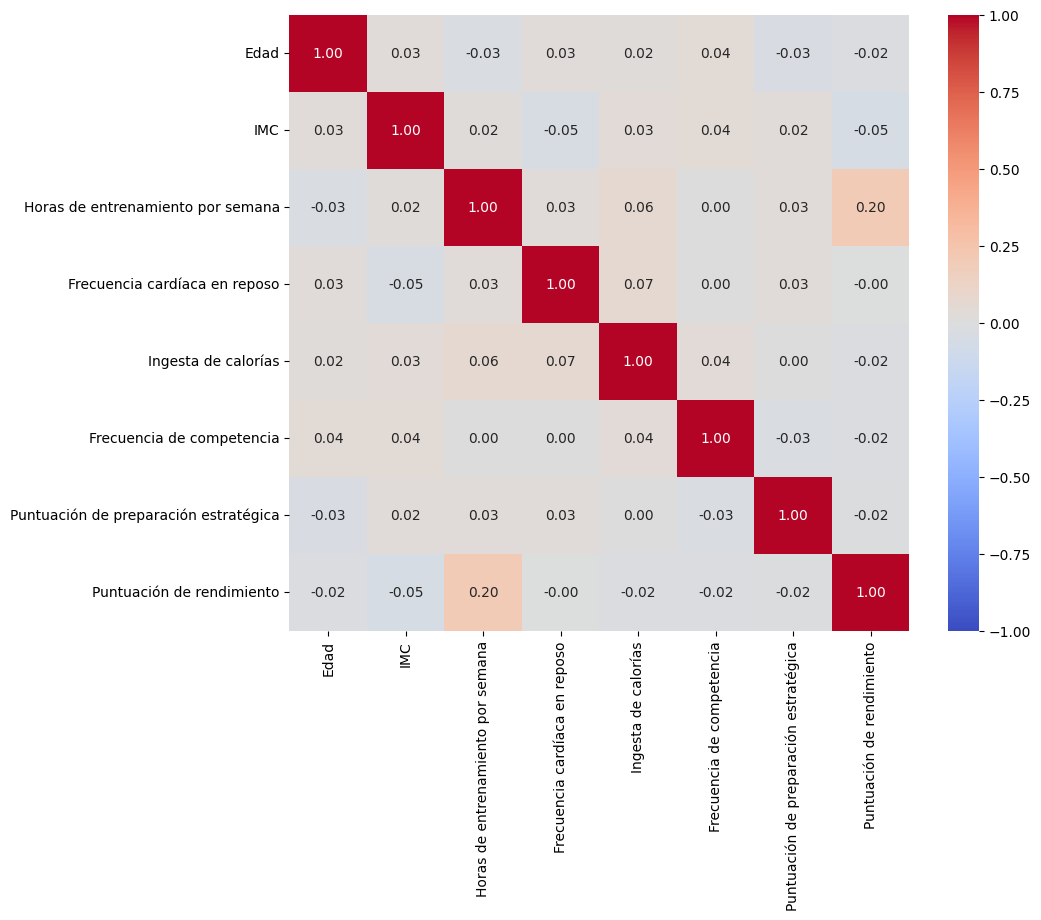

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[num_cols + [target]].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.show()

# Corrección de errores de calidad de datos

Estrategia: los errores **deterministas/sistemáticos** (recodificar categorías, corregir unidades, quitar filas idénticas) se corrigen **ahora**, antes de separar train/test. La imputación estadística de nulos (media/mediana/moda) se deja para el **pipeline** del punto 4, porque esas estadísticas deben aprenderse solo del set de entrenamiento — imputar ahora, con todo el dataset junto, sería fuga de información (data leakage).

Orden de corrección (importa): Género → Edad → Frecuencia de competencia → duplicados. Se deja duplicados al final porque, como se ve abajo, corregir Edad revela un duplicado que antes estaba oculto.

## Consistencia — `Género`
En el Paso 3 vimos 4 categorías en vez de 2: "Masculino"/"M" y "Femenino"/"F" son la misma categoría escrita distinto. Se unifican con un mapeo antes de codificar.

In [24]:
data['Género'] = data['Género'].replace({'M': 'Masculino', 'F': 'Femenino'})
data['Género'].value_counts(dropna=False)

Género
Masculino    650
Femenino     341
NaN            9
Name: count, dtype: int64

## Exactitud — `Edad`
En el `describe()` del Paso 2 el máximo de Edad era 492, imposible para una persona. Revisando los percentiles se ve un salto brusco después de 20, y **todos los valores mayores a 60 son múltiplos exactos de 12**; divididos entre 12 caen entre 15 y 41 años, un rango perfectamente plausible para atletas. No es un valor aislado: es un error sistemático de unidad — la edad quedó registrada en **meses** en vez de años en la mayoría de los registros. Se corrige dividiendo entre 12 los valores mayores a 60.

In [25]:
data.loc[data['Edad'] > 60, 'Edad'] = data.loc[data['Edad'] > 60, 'Edad'] / 12
data['Edad'].describe()

count    994.000000
mean      28.045272
std        7.374664
min       15.000000
25%       21.000000
50%       29.000000
75%       34.000000
max       41.000000
Name: Edad, dtype: float64

## Exactitud — `Frecuencia de competencia`
El mínimo era -1.01: una frecuencia de competencia no puede ser negativa. Son 28 registros, todos con magnitudes pequeñas cercanas a cero, consistentes con un error de signo en la captura. En vez de asumir un valor arbitrario (ej. tomar el valor absoluto), se tratan como dato inválido y se convierten a nulo, para que se imputen junto con el resto de faltantes dentro del pipeline.

In [26]:
data.loc[data['Frecuencia de competencia'] < 0, 'Frecuencia de competencia'] = np.nan
data['Frecuencia de competencia'].describe()

count    960.000000
mean      12.520752
std        7.074653
min        0.010795
25%        6.477972
50%       12.570605
75%       19.014556
max       25.312736
Name: Frecuencia de competencia, dtype: float64

## Unicidad — duplicados
Antes de corregir Edad, el registro `log_id=247549` parecía tener dos versiones "distintas" (Edad=240 vs Edad=20 meses/años), por lo que `duplicated()` no lo detectaba como duplicado exacto. Ahora que Edad está en la misma unidad, ese par queda idéntico y se elimina junto con el resto de duplicados exactos.

In [27]:
print('Filas antes:', data.shape[0])
print('Duplicados exactos detectados:', data.duplicated(subset=[c for c in data.columns if c != 'log_id']).sum())

data = data.drop_duplicates(subset=[c for c in data.columns if c != 'log_id'], keep='first')
print('Filas después de eliminar duplicados:', data.shape[0])

Filas antes: 1000
Duplicados exactos detectados: 5
Filas después de eliminar duplicados: 995


## Completitud — nulos restantes
Tras las correcciones anteriores (que en `Frecuencia de competencia` incluso agregaron nuevos nulos, a propósito), se recalculan los faltantes. Estos se dejan tal cual: se imputarán dentro del **pipeline** (mediana para numéricas, moda para categóricas) usando estadísticas aprendidas solo del set de entrenamiento, para no filtrar información del test.

In [29]:
(data.isnull().sum() / data.shape[0] * 100).sort_values(ascending=False)

Frecuencia de competencia                    4.020101
Tipo de deporte                              1.407035
Nivel de experiencia                         1.306533
Horas de entrenamiento por semana            1.206030
Ingesta de calorías                          1.206030
IMC                                          1.105528
Frecuencia cardíaca en reposo                1.105528
Indicador de establecimiento de objetivos    1.005025
Género                                       0.904523
Puntuación de preparación estratégica        0.804020
Edad                                         0.603015
Puntuación de rendimiento                    0.000000
log_id                                       0.000000
dtype: float64

# Pipeline

In [35]:
data.describe()

,Edad,IMC,Horas de entrenamiento por semana,Frecuencia cardíaca en reposo,Ingesta de calorías,Frecuencia de competencia,Puntuación de preparación estratégica,Puntuación de rendimiento,log_id
count,989.000000,984.000000,983.000000,984.000000,983.000000,955.000000,987.000000,995.000000,995.000000
mean,28.034378,22.993401,19.847032,67.744098,3173.401062,12.485953,65.057919,82.599733,126962.458291
std,7.368883,3.026150,9.106233,13.270272,833.332808,7.072254,14.843886,12.832838,71533.587043
min,15.000000,15.871890,4.381193,43.977092,1757.476349,0.010795,19.059695,32.211629,86.000000
25%,21.000000,20.891411,12.248239,56.138690,2525.770184,6.450504,54.709308,73.761435,65139.500000
50%,29.000000,23.056965,19.389148,68.141327,3165.608545,12.487703,64.543524,83.714466,127438.000000
75%,34.000000,25.036724,27.502870,78.582449,3836.197014,18.910007,75.877142,92.905105,187545.500000
max,41.000000,34.981132,68.990598,114.023258,7225.519216,25.312736,100.758629,101.567375,249061.000000


In [32]:
# Separar X y y
X = data.drop(columns=['Puntuación de rendimiento', 'log_id'])
y = data['Puntuación de rendimiento']

In [33]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Grupos de columnas

numeric_cols = ['Edad', 'IMC', 'Horas de entrenamiento por semana', 'Frecuencia cardíaca en reposo', 'Ingesta de calorías', 'Puntuación de preparación estratégica', 'Frecuencia de competencia']
ordinal_cols = ['Nivel de experiencia', 'Indicador de establecimiento de objetivos']
nominal_cols = ['Género', 'Tipo de deporte']

In [38]:
# Sub-pipeline de imputacion

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[
        ['Principiante', 'Intermedio', 'Avanzado', 'Profesional'],
        ['No', 'Sí']
    ])
    )
])

nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('ord', ordinal_transformer, ordinal_cols),
    ('nom', nominal_transformer, nominal_cols)
])

# Fit_transform en train
X_train_prep = preprocessor.fit_transform(X_train)

# Transform en test
X_test_prep = preprocessor.transform(X_test)

In [39]:
X_test_prep_df = pd.DataFrame(X_test_prep, columns=preprocessor.get_feature_names_out())
display(X_test_prep_df.head())

,num__Edad,num__IMC,num__Horas de entrenamiento por semana,num__Frecuencia cardíaca en reposo,num__Ingesta de calorías,num__Puntuación de preparación estratégica,ord__Nivel de experiencia,ord__Indicador de establecimiento de objetivos,nom__Género_Femenino,nom__Género_Masculino,nom__Tipo de deporte_Atletismo,nom__Tipo de deporte_Baloncesto,nom__Tipo de deporte_Ciclismo,nom__Tipo de deporte_Fútbol americano,nom__Tipo de deporte_Natación,nom__Tipo de deporte_Tenis
0,0.243881,0.353216,-0.132112,-1.496458,-1.450143,-0.019967,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-1.543431,0.403763,-0.546208,-1.219845,-1.168167,0.065092,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.856003,2.145143,0.286990,1.011954,-0.174100,0.898798,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-1.543431,-1.316016,1.258682,-0.975028,0.126190,0.481512,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-1.405946,0.160121,-0.199446,0.439350,-0.657573,0.380449,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe(include='all')

In [ ]:
df.describe(include=['object', 'category'])

In [ ]:
df.columns

In [ ]:
df.isnull().sum()

In [ ]:
df.isna().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df.drop(columns=['columna_1'], inplace=True)

In [ ]:
df.dropna(subset=["col1"])

In [ ]:
df.fillna(df['col2'].median(), inplace=True)

In [ ]:
df["columna"]

In [ ]:
df["Columna_nueva"] = 1

In [ ]:
df["Columna_nueva"] = df["col1"] * 2

In [ ]:
df['Vista'] = df['Vista'].abs()

In [ ]:
df['Vista'] = df['Vista'].astype(str).str[0].astype(int)

In [ ]:
df["Columna_nueva_2"] = np.where(df['col3'] > 1000000,1,0)

data.loc[data['FrenteMar'] == 'no', 'FrenteMar'] = 'NO'

In [ ]:
df[['col1', 'col2', 'col3', 'col4']]

In [ ]:
df['Columna_nueva_2'].value_counts()

In [ ]:
pd.crosstab(df['col1_cat'], df['col2_cat'])

In [ ]:
display(df['columna_categorica'].unique())
display(df['columna_categorica'].nunique())

In [ ]:
df[df['col1'] > 1000000]

df[df['col1'] == "valor_especifico"]

df.loc[df.loc[:,'col2']==795000620]

df[(df['col1'] < 0) | (data['col1'] > 4)].copy()

In [ ]:
data['Fecha'] = pd.to_datetime(data['Fecha'], format='%Y%m%dT%H%M%S')

data = data.sort_values(['Id', 'Fecha'], ascending=[True, False])

In [ ]:
encoder = OrdinalEncoder(categories=[['NO', 'SI']])

In [ ]:
df['FrenteMar'] = encoder.fit_transform(df[['FrenteMar']]).astype(int)

In [ ]:
df['variable_binaria'] = df['variable_texto'].map({'NO': 0, 'SI': 1})

In [ ]:

# =========================================================
# Transformaciones Previas (Fuera del Pipeline)
# =========================================================

df = df.drop_duplicates(subset=["Cuartos",'Baños'],keep='last')

In [ ]:
((df.isnull().sum()/df.shape[0])).sort_values(ascending=False)

In [ ]:
nulos = df[df['Calificación'].isna()].copy()

In [ ]:
indices = data.index[data['Calificación'].isna()]

In [ ]:
data.loc[indices]

In [ ]:
df_media = df.groupby('columna_categorica')['columna_numerica'].mean().reset_index()

df_agrupado = df.groupby('columna_categorica').agg({
    'columna_num1': 'mean',
    'columna_num2': ['sum', 'count', 'max']
}).reset_index()

df_conteo = df.groupby(['cat1', 'cat2']).size().reset_index(name='conteo')

In [ ]:
dup_counts = (data[["Id","Precio"]].groupby('Id').size().reset_index(name='Count').sort_values(by='Count', ascending=False))

dup_counts= dup_counts[dup_counts['Count']>1]

for id_, n in dup_counts[["Id","Count"]].values:    
    print(f"Id={id_} → {n} apariciones")

In [ ]:

dup_table = (
    data[data['Id'].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=data.groupby('Id')['Id'].transform('size'))
    .sort_values(['repeticiones', 'Id'], ascending=[False, True])
)

In [ ]:

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
if 'target' in numeric_cols: numeric_cols.remove('target')

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[~((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR)))]

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()


In [ ]:
sns.heatmap(data.corr(numeric_only=True))

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].scatter(data['Calificación'], data['AreaHabitable']); ax[0].set_title('Calificación vs AreaHabitable')
ax[1].scatter(data['Calificación'], data['AreaSuperior']); ax[1].set_title('Calificación vs AreaSuperior')
ax[2].scatter(data['Calificación'], data['AreaHabitable15']); ax[2].set_title('Calificación vs AreaHabitable15')

plt.tight_layout()
plt.show()

In [ ]:
df.hist(bins=30, figsize=(15, 10))
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['columna_numerica'])
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='columna_categorica', y='columna_numerica', data=df)
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x='columna_categorica', data=df)
plt.show()

plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.show()

sns.pairplot(df, hue='target')
plt.show()

In [ ]:
sns.histplot(data=df, x='columna_numerica', kde=True, bins=30)
plt.show()

sns.boxplot(data=df, x='columna_categorica', y='columna_numerica')
plt.show()

sns.countplot(data=df, x='columna_categorica', order=df['columna_categorica'].value_counts().index)
plt.show()

sns.scatterplot(data=df, x='columna_num1', y='columna_num2', hue='columna_categorica')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [ ]:
k = (data['Calificación'] / data['AreaHabitable']).dropna().median()


data= data.fillna({'Calificación': k * data['AreaHabitable']})
# Alternativa:
data.loc[data['Calificación'].isna(), 'Calificación'] = k * data['AreaHabitable']


data['Calificación'] = data['Calificación'].round()

data['Calificación'] = data['Calificación'].clip(lower=1, upper=13)

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cols = encoder.fit_transform(df[['columna_categorica']])

df_encoded = pd.DataFrame(
    encoded_cols, 
    columns=encoder.get_feature_names_out(['columna_categorica'])
)

df = pd.concat([df.drop('columna_categorica', axis=1), df_encoded], axis=1)

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.show()

X = df.drop('target', axis=1)
y = df['target']

smote = SMOTE(random_state=42)
X_over, y_over = smote.fit_resample(X, y)

rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X, y)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_over, ax=axes[0])
sns.countplot(x=y_under, ax=axes[1])

plt.tight_layout()
plt.show()

In [ ]:

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Aplicación sobre los datos de entrenamiento
X_train_preparado = preprocessor.fit_transform(X_train)

# Visualización del resultado transformado
X_train_df_prep = pd.DataFrame(
    X_train_preparado, 
    columns=preprocessor.get_feature_names_out()
)
display(X_train_df_prep.head())